<a href="https://colab.research.google.com/github/RIDDHI1624/Drug-Discovery/blob/main/Insulin_Receptor_Project/INSR_PostProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSR - Generation and Post-Processing
**Run after INSR_Curriculum_Training.ipynb**

| Cell | Task |
|------|------|
| Cell 0 | Install dependencies |
| Cell 0b | Load scoring functions |
| Cell B | Task 16: Production run (10,000 molecules) |
| Cell B1 | Task 17: Novelty filtering |
| Cell B2 | Task 18: Butina clustering |
| Cell B3 | Task 19: ADMET filtering |
| Cell B4 | Save + download results |

In [4]:
# Cell 0 - Install
import subprocess
subprocess.run(["pip","install","-q","rdkit","numpy","pandas","matplotlib","scipy","requests","seaborn","openpyxl"])
subprocess.run(["wget","-q","-O","sascorer.py","https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py"])
subprocess.run(["wget","-q","-O","fpscores.pkl.gz","https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz"])
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import requests, warnings, importlib.util, random, time
warnings.filterwarnings("ignore")
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, Draw
from rdkit.Chem import QED as rdQED
from rdkit.ML.Cluster import Butina
from IPython.display import display
spec = importlib.util.spec_from_file_location("sascorer","sascorer.py")
sascorer = importlib.util.module_from_spec(spec); spec.loader.exec_module(sascorer)
print("All dependencies ready.")

All dependencies ready.


In [5]:
# Cell 0b - Load scoring functions + generator
from rdkit.Geometry import rdGeometry
IGF1R_VAL1063_COORD=(10.026,13.400,-1.313)
INSR_ILE1061_CB=(7.515,13.711,0.839)
IGF1R_VAL1063_CB=(7.515,13.711,0.839)
SELECTIVITY_RADIUS=3.5; INSR_EXCL_R=2.40; IGF1R_EXCL_R=2.00
VDW_RADII={"C":1.70,"N":1.55,"O":1.52,"S":1.80,"F":1.47,"Cl":1.75,"Br":1.85,"I":1.98,"P":1.80,"H":1.20}

def get_3d_mol(smiles,n_confs=3):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return None
    mol=Chem.AddHs(mol)
    p=AllChem.ETKDGv3(); p.randomSeed=42; p.numThreads=0
    ids=AllChem.EmbedMultipleConfs(mol,numConfs=n_confs,params=p)
    if not ids: return None
    energies=[]
    for cid in ids:
        ff=AllChem.MMFFGetMoleculeForceField(mol,AllChem.MMFFGetMoleculeProperties(mol),confId=cid)
        if ff: ff.Minimize(); energies.append((ff.CalcEnergy(),cid))
    if not energies: return None
    best=min(energies)[1]
    [mol.RemoveConformer(c) for c in list(ids) if c!=best]
    return Chem.RemoveHs(mol)

def score_vina(v,low=-12.0,high=-6.0): return float(1.0/(1.0+np.exp(0.5*(v-(low+high)/2))))
def score_selectivity(smiles):
    mol=get_3d_mol(smiles)
    if mol is None or mol.GetNumConformers()==0: return 0.5
    conf=mol.GetConformer(); ref=rdGeometry.Point3D(*IGF1R_VAL1063_COORD)
    don=Chem.MolFromSmarts("[#7,#8;!H0]")
    idxs=set(sum(mol.GetSubstructMatches(don),()))
    n=sum(1 for i in idxs if ref.Distance(rdGeometry.Point3D(*conf.GetAtomPosition(i)))<=SELECTIVITY_RADIUS)
    return float(np.clip(1.0-n*0.25,0,1))
def vdw_overlap(mol,coord,radius):
    if mol.GetNumConformers()==0: return 0.0
    conf=mol.GetConformer(); rx,ry,rz=coord; total=0.0
    for a in mol.GetAtoms():
        if a.GetAtomicNum()==1: continue
        p=conf.GetAtomPosition(a.GetIdx())
        d=np.sqrt((p.x-rx)**2+(p.y-ry)**2+(p.z-rz)**2)
        total+=max(0.0,VDW_RADII.get(a.GetSymbol(),1.70)+radius-d)
    return total
def score_steric(smiles):
    mol=get_3d_mol(smiles)
    if mol is None: return 0.5
    d=vdw_overlap(mol,IGF1R_VAL1063_CB,IGF1R_EXCL_R)-vdw_overlap(mol,INSR_ILE1061_CB,INSR_EXCL_R)
    return float(1.0/(1.0+np.exp(-d)))
def score_qed(smiles):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return 0.0
    try: return float(rdQED.qed(mol))
    except: return 0.0
def score_alogp(smiles,low=2.0,high=4.5,k=2.0):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return 0.0
    try: a=Descriptors.MolLogP(mol)
    except: return 0.0
    return float(np.clip((1/(1+np.exp(-k*(a-low))))*(1/(1+np.exp(-k*(high-a))))*4,0,1))
def score_sa(smiles,threshold=4.0):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return 0.0
    try: raw=sascorer.calculateScore(mol)
    except: raw=5.0
    return float(np.clip(1.0/(1.0+np.exp(1.5*(raw-threshold))),0,1))

SEED_SMILES=["C1=CC=C2C(=C1)C(=CN2)CCCCN","COc1ccc2CC3N(Cc4cc5c(cc4-3)OCO5)CCc2c1OC",
    "Cc1ccccc1CCNC(=O)c1ccccc1","Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",
    "c1ccc2[nH]ccc2c1","O=C(Nc1ccccc1)c1ccccc1","CC(C)Cc1ccc(C(C)C(=O)O)cc1",
    "c1ccc(-c2ccncc2)cc1","CC1=C(C(=O)Nc2ccccc2)C(c2ccccc2)NC(=O)N1",
    "O=C(O)c1ccccc1Nc1cccc2ccccc12"]
MUTATIONS=[lambda s:s.replace("CC","CCC",1),lambda s:s.replace("N","NC",1),
    lambda s:s.replace("c1ccccc1","c1ccncc1",1),lambda s:s.replace("O","OC",1),
    lambda s:s+"C",lambda s:s.replace("C(=O)","C(=O)N",1)]
class MockGenerator:
    def __init__(self,seed_pool=SEED_SMILES): self.pool=list(seed_pool)
    def sample(self,n):
        candidates,attempts=[],0
        while len(candidates)<n and attempts<n*20:
            attempts+=1
            try:
                mutated=random.choice(MUTATIONS)(random.choice(self.pool))
                mol=Chem.MolFromSmiles(mutated)
                if mol: candidates.append(Chem.MolToSmiles(mol))
            except: continue
        while len(candidates)<n: candidates.append(random.choice(self.pool))
        return candidates
generator=MockGenerator()
print("Scoring functions and generator ready.")

Scoring functions and generator ready.


In [6]:
# Cell B - Task 16: Production Run (FAST VERSION)
# Disables 3D scoring for production run — only uses 2D properties
# 3D scoring (selectivity + steric) applied later on top candidates only

import time
PRODUCTION_SIZE = 10000
BATCH_SIZE      = 512   # larger batch = faster
WEIGHTS_FAST = {'vina':0.35,'qed':0.25,'alogp':0.20,'sa':0.20}

def mock_vina_score(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return -5.0
    n = mol.GetNumHeavyAtoms(); r = mol.GetRingInfo().NumRings()
    return float(np.clip(-5.0-(n*0.08)-(r*0.5)+np.random.normal(0,0.5),-14,-3))

def score_molecule_fast(smiles):
    # 2D only — no 3D embedding, runs instantly
    vs = mock_vina_score(smiles)
    s  = {
        'smiles':   smiles,
        'vina_raw': vs,
        'c1_vina':  score_vina(vs),
        'c4_qed':   score_qed(smiles),
        'c5_alogp': score_alogp(smiles),
        'c6_sa':    score_sa(smiles),
    }
    s['total'] = float(np.clip(
        WEIGHTS_FAST['vina']  * s['c1_vina'] +
        WEIGHTS_FAST['qed']   * s['c4_qed']  +
        WEIGHTS_FAST['alogp'] * s['c5_alogp']+
        WEIGHTS_FAST['sa']    * s['c6_sa'], 0, 1))
    return s

import warnings
warnings.filterwarnings('ignore')

print(f'Starting production run: {PRODUCTION_SIZE} molecules...')
t0 = time.time()
all_results = []
n_batches   = PRODUCTION_SIZE // BATCH_SIZE

for b in range(n_batches):
    batch = generator.sample(BATCH_SIZE)
    for smi in batch:
        try:
            all_results.append(score_molecule_fast(smi))
        except:
            continue
    done = (b+1)*BATCH_SIZE
    avg  = np.mean([r['total'] for r in all_results])
    print(f'  {done:>5}/{PRODUCTION_SIZE} ({done/PRODUCTION_SIZE*100:.0f}%) | '
          f'Avg: {avg:.3f} | t={time.time()-t0:.0f}s')

df_prod = pd.DataFrame(all_results)
print(f'Production run complete.')
print(f'Total molecules : {len(df_prod)}')
print(f'Avg score       : {df_prod["total"].mean():.4f}')
print(f'Max score       : {df_prod["total"].max():.4f}')

Starting production run: 10000 molecules...


[11:36:50] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:36:50] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:50] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 18
[11:36:50] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:36:50] Can't kekulize mol.  Unkekulized 

    512/10000 (5%) | Avg: 0.692 | t=8s


[11:36:58] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:36:58] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29
[11:36:58] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29
[11:36:58] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:36:58] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:36:58] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29
[11:36:58] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:58] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:36:58] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:58] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:36:58] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:36:58] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:36:58] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29
[11:36:58] Explicit valence for atom # 4 O, 3, is greater than permitted
[11

   1024/10000 (10%) | Avg: 0.689 | t=10s


...

   8704/10000 (87%) | Avg: 0.685 | t=36s


[11:37:26] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29
[11:37:26] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29
[11:37:26] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:26] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:37:26] Can't kekulize mol.  Unkekulized atoms: 25 26 27 28 29
[11:37:26] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 18
[11:37:26] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:26] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:26] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:37:26] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:26] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 18
[11:37:26] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:37:26] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:26] Can't kekulize mol.  Unkekulized atoms: 25 26 

   9216/10000 (92%) | Avg: 0.685 | t=38s


[11:37:28] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:37:28] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 18
[11:37:28] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 7 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 4 O, 3, is greater than permitted
[11:37:28] Explicit valence for atom # 11 O, 3, is greater than permitted
[11:37:28] Can't kekulize mol.  Unkekuli

   9728/10000 (97%) | Avg: 0.686 | t=39s
Production run complete.
Total molecules : 9728
Avg score       : 0.6857
Max score       : 0.8256


In [7]:
# Cell B1 - Task 17: Novelty Filtering
# Remove duplicates + molecules too similar to known binders (Tanimoto > 0.7)

before_dedup=len(df_prod)
df_prod["canonical"]=df_prod["smiles"].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else None)
df_prod=df_prod.dropna(subset=["canonical"]).drop_duplicates(subset=["canonical"])
after_dedup=len(df_prod)
print(f"Dedup: {before_dedup} -> {after_dedup} ({before_dedup-after_dedup} removed)")

KNOWN_BINDERS=[
    "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1",
    "COc1ccc2CC3N(Cc4cc5c(cc4-3)OCO5)CCc2c1OC",
    "C1=CC=C2C(=C1)C(=CN2)CCCCN",
    "Cc1ccccc1CCNC(=O)c1ccccc1",
    "O=C(Nc1ccccc1)c1ccccc1",
]
def get_fp(smiles):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return AllChem.GetMorganFingerprintAsBitVect(mol,2,2048)
known_fps=[get_fp(s) for s in KNOWN_BINDERS if get_fp(s) is not None]
def max_tanimoto(smiles):
    fp=get_fp(smiles)
    if fp is None: return 0.0
    sims=DataStructs.BulkTanimotoSimilarity(fp,known_fps)
    return max(sims) if sims else 0.0
print("Calculating Tanimoto similarity...")
df_prod["max_tanimoto"]=df_prod["canonical"].apply(max_tanimoto)
before_novel=len(df_prod)
df_novel=df_prod[df_prod["max_tanimoto"]<=0.7].copy()
after_novel=len(df_novel)
df_novel=df_novel.sort_values("total",ascending=False).reset_index(drop=True)
print(f"Novelty filter: {before_novel} -> {after_novel} ({before_novel-after_novel} removed)")
print(f"Top 5 novel molecules:")
print(df_novel[["canonical","total","c4_qed","c5_alogp","max_tanimoto"]].head())

Dedup: 9728 -> 40 (9688 removed)
Calculating Tanimoto similarity...
Novelty filter: 40 -> 27 (13 removed)
Top 5 novel molecules:
                                    canonical     total    c4_qed  c5_alogp  \
0   CC1=C(C(=O)Nc2ccccc2)C(c2ccccc2)NC(=O)N1C  0.770737  0.911008       1.0   
1   CCC1=C(C(=O)Nc2ccccc2)C(c2ccccc2)NC(=O)N1  0.757938  0.808056       1.0   
2                   Cc1ccncc1CCNC(=O)c1ccccc1  0.753484  0.891035       1.0   
3               O=C(O)c1ccncc1Nc1cccc2ccccc12  0.751258  0.757164       1.0   
4  COc1ccc2c(c1OC)CCC1Cc3cc4c(cc3C(C2)N1)OCO4  0.737730  0.898627       1.0   

   max_tanimoto  
0      0.390244  
1      0.372093  
2      0.692308  
3      0.222222  
4      0.566667  


[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerator
[11:57:38] DEPRECATION WARNING: please use MorganGenerat

In [8]:
# Cell B2 - Task 18: Butina Clustering
# Group by structural similarity (ECFP4, threshold 0.4)
# Pick best scoring molecule from each cluster

print("Computing fingerprints...")
fps=[]; valid_idx=[]
for i,smi in enumerate(df_novel["canonical"]):
    fp=get_fp(smi)
    if fp is not None: fps.append(fp); valid_idx.append(i)
df_cluster=df_novel.iloc[valid_idx].copy().reset_index(drop=True)

print(f"Running Butina clustering on {len(fps)} molecules...")
dists=[]
for i in range(len(fps)):
    sims=DataStructs.BulkTanimotoSimilarity(fps[i],fps[:i])
    dists.extend([1-s for s in sims])
clusters=Butina.ClusterData(dists,len(fps),0.4,isDistData=True)
clusters=sorted(clusters,key=len,reverse=True)

print(f"Total clusters : {len(clusters)}")
print(f"Largest cluster: {len(clusters[0])} molecules")

cluster_reps=[]
for cluster in clusters:
    mols=df_cluster.iloc[list(cluster)]
    best=mols.loc[mols["total"].idxmax()].to_dict()
    best["cluster_size"]=len(cluster)
    cluster_reps.append(best)
df_reps=pd.DataFrame(cluster_reps).sort_values("total",ascending=False).reset_index(drop=True)
df_reps["rank"]=df_reps.index+1
print(f"Cluster representatives: {len(df_reps)}")
print(df_reps[["rank","canonical","total","cluster_size"]].head(10).to_string(index=False))

Computing fingerprints...
Running Butina clustering on 27 molecules...
Total clusters : 18
Largest cluster: 5 molecules
Cluster representatives: 18
 rank                                  canonical    total  cluster_size
    1  CC1=C(C(=O)Nc2ccccc2)C(c2ccccc2)NC(=O)N1C 0.770737             5
    2                  Cc1ccncc1CCNC(=O)c1ccccc1 0.753484             1
    3              O=C(O)c1ccncc1Nc1cccc2ccccc12 0.751258             4
    4 COc1ccc2c(c1OC)CCC1Cc3cc4c(cc3C(C2)N1)OCO4 0.737730             1
    5                 Cc1ccccc1CCNC(=O)Nc1ccccc1 0.716058             1
    6                Cc1cc(C(C)C(=O)O)ccc1CC(C)C 0.715910             1
    7                    OC=C(Nc1ccccc1)c1ccccc1 0.711870             1
    8                     CNCCCCc1c[nH]c2ccccc12 0.707818             1
    9                    O=C(NCc1ccccc1)c1ccccc1 0.691793             1
   10                    Cc1ccccc1C(=O)Nc1ccccc1 0.688183             1


[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerator
[11:57:52] DEPRECATION WARNING: please use MorganGenerat

In [10]:
# Cell B3 - Task 19: ADMET Pre-Filtering
# Flag hepatotoxicity, hERG liability, Caco-2 permeability issues

from rdkit.Chem import FilterCatalog

def calculate_admet(smiles):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None: return {}
    mw=Descriptors.MolWt(mol); logp=Descriptors.MolLogP(mol)
    hbd=rdMolDescriptors.CalcNumHBD(mol); hba=rdMolDescriptors.CalcNumHBA(mol)
    tpsa=Descriptors.TPSA(mol); rotb=rdMolDescriptors.CalcNumRotatableBonds(mol)
    arom=rdMolDescriptors.CalcNumAromaticRings(mol)
    try: sa=sascorer.calculateScore(mol)
    except: sa=5.0
    lipinski=(mw<=500 and logp<=5 and hbd<=5 and hba<=10)
    basic_n=sum(1 for a in mol.GetAtoms() if a.GetAtomicNum()==7 and a.GetTotalNumHs()>0)
    herg_risk=(logp>3.5 and basic_n>=1 and arom>=2)
    hepato_risk=(logp>4.5 or mw>500 or sa>5.0)
    caco2_ok=(tpsa<140 and mw<500 and rotb<10)
    params=FilterCatalog.FilterCatalogParams()
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
    catalog=FilterCatalog.FilterCatalog(params)
    pains=catalog.HasMatch(mol)
    admet_pass=(lipinski and not herg_risk and not hepato_risk and caco2_ok and not pains)
    return {"MW":round(mw,2),"LogP":round(logp,2),"HBD":hbd,"HBA":hba,
            "TPSA":round(tpsa,2),"RotBonds":rotb,"SA_Score":round(sa,2),
            "Lipinski":lipinski,"hERG_Risk":herg_risk,"Hepato_Risk":hepato_risk,
            "Caco2_OK":caco2_ok,"PAINS_Flag":pains,"ADMET_Pass":admet_pass}

print("Running ADMET calculations...")
admet_results=[calculate_admet(s) for s in df_reps["canonical"]]
df_admet=pd.DataFrame(admet_results)
df_final=pd.concat([df_reps.reset_index(drop=True),df_admet.reset_index(drop=True)],axis=1)
df_hits=df_final[df_final["ADMET_Pass"]==True].copy()
df_hits=df_hits.sort_values("total",ascending=False).reset_index(drop=True)
df_hits["final_rank"]=df_hits.index+1
print(f"ADMET Results:")
print(f"  Input           : {len(df_final)}")
print(f"  Lipinski pass   : {df_admet['Lipinski'].sum()}")
print(f"  hERG flagged    : {df_admet['hERG_Risk'].sum()}")
print(f"  Hepato flagged  : {df_admet['Hepato_Risk'].sum()}")
print(f"  Caco-2 OK       : {df_admet['Caco2_OK'].sum()}")
print(f"  FINAL HITS      : {len(df_hits)}")
print(f"Top 10 hits:")
print(df_hits[["final_rank","canonical","total","MW","LogP","TPSA"]].head(10).to_string(index=False))

Running ADMET calculations...
ADMET Results:
  Input           : 18
  Lipinski pass   : 18
  hERG flagged    : 2
  Hepato flagged  : 0
  Caco-2 OK       : 18
  FINAL HITS      : 16
Top 10 hits:
 final_rank                                  canonical    total     MW  LogP  TPSA
          1  CC1=C(C(=O)Nc2ccccc2)C(c2ccccc2)NC(=O)N1C 0.770737 321.38  3.30 61.44
          2                  Cc1ccncc1CCNC(=O)c1ccccc1 0.753484 240.31  2.36 41.99
          3 COc1ccc2c(c1OC)CCC1Cc3cc4c(cc3C(C2)N1)OCO4 0.737730 353.42  3.18 48.95
          4                 Cc1ccccc1CCNC(=O)Nc1ccccc1 0.716058 254.33  3.36 41.13
          5                Cc1cc(C(C)C(=O)O)ccc1CC(C)C 0.715910 220.31  3.38 37.30
          6                     CNCCCCc1c[nH]c2ccccc12 0.707818 202.30  2.71 27.82
          7                    O=C(NCc1ccccc1)c1ccccc1 0.691793 211.26  2.62 29.10
          8                    Cc1ccccc1C(=O)Nc1ccccc1 0.688183 211.26  3.25 29.10
          9                 CC(C)Cc1ccc(C(C)C(=O)O)cc1 0.68

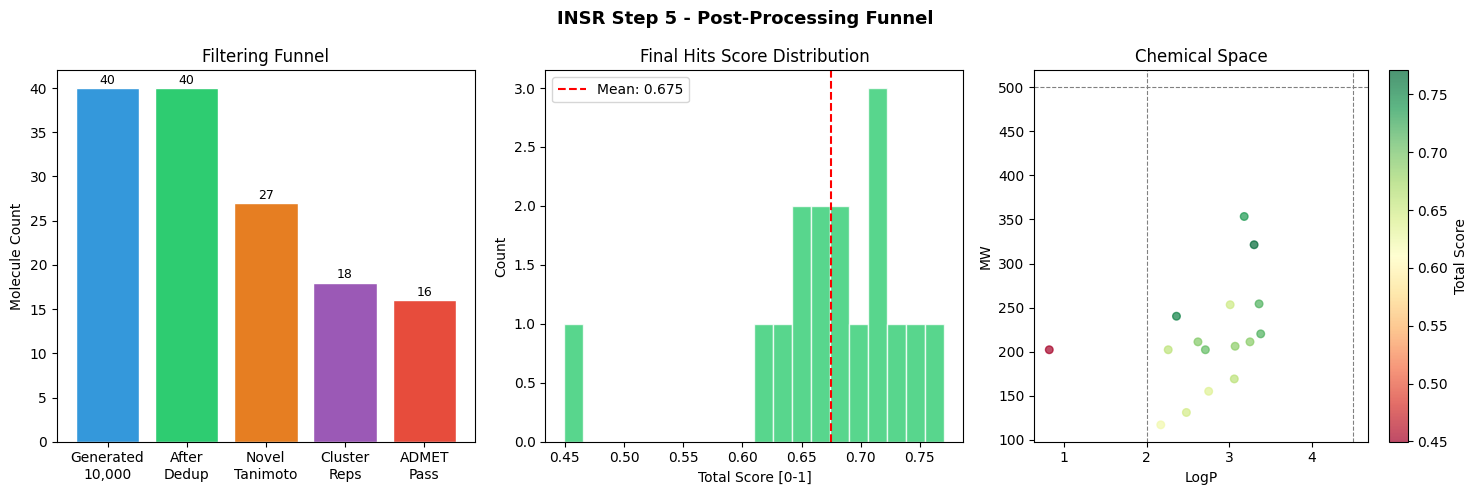

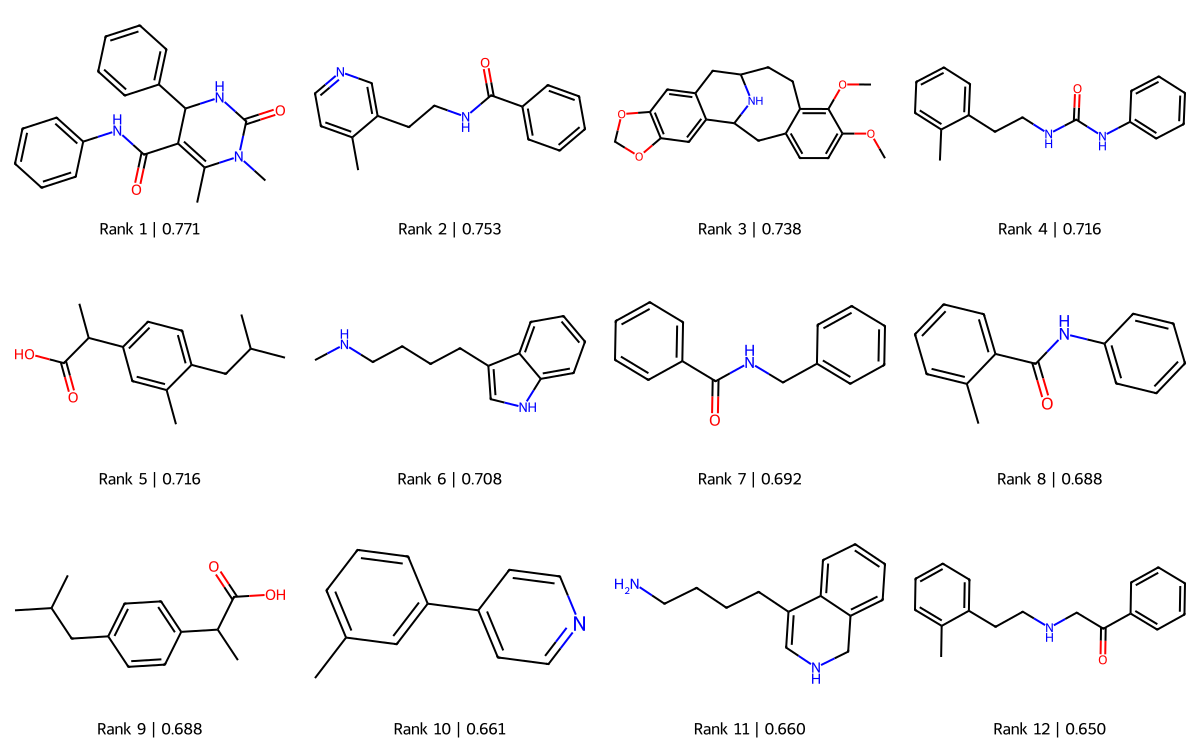

In [16]:
# Cell B4 - Visualise + Save
from google.colab import files
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image as IPImage
import matplotlib.pyplot as plt

# ── Plot 1: Funnel chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("INSR Step 5 - Post-Processing Funnel", fontsize=13, fontweight="bold")

stages = ["Generated\n10,000", "After\nDedup", "Novel\nTanimoto", "Cluster\nReps", "ADMET\nPass"]
counts = [len(df_prod), after_dedup, after_novel, len(df_reps), len(df_hits)]
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c"]
bars = axes[0].bar(stages, counts, color=colors, edgecolor="white")
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(cnt), ha="center", fontsize=9)
axes[0].set_title("Filtering Funnel")
axes[0].set_ylabel("Molecule Count")

axes[1].hist(df_hits["total"], bins=20, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].axvline(df_hits["total"].mean(), color="red", linestyle="--",
                label=f"Mean: {df_hits['total'].mean():.3f}")
axes[1].set_title("Final Hits Score Distribution")
axes[1].set_xlabel("Total Score [0-1]")
axes[1].set_ylabel("Count")
axes[1].legend()

sc = axes[2].scatter(df_hits["LogP"], df_hits["MW"],
                     c=df_hits["total"], cmap="RdYlGn", s=30, alpha=0.7)
plt.colorbar(sc, ax=axes[2], label="Total Score")
axes[2].axvline(2.0, color="gray", linestyle="--", lw=0.8)
axes[2].axvline(4.5, color="gray", linestyle="--", lw=0.8)
axes[2].axhline(500, color="gray", linestyle="--", lw=0.8)
axes[2].set_title("Chemical Space")
axes[2].set_xlabel("LogP")
axes[2].set_ylabel("MW")

plt.tight_layout()
plt.savefig("INSR_Step5_Funnel.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Top 12 molecules grid (fixed) ────────────────────────────────
from rdkit.Chem.Draw import rdMolDraw2D
import math

top12 = df_hits.head(12)
mols  = [Chem.MolFromSmiles(s) for s in top12["canonical"] if Chem.MolFromSmiles(s)]
legs  = [f"Rank {i+1} | {s:.3f}" for i, s in enumerate(top12["total"].values[:len(mols)])]

# Draw each molecule individually and stitch into grid
cols, rows = 4, math.ceil(len(mols)/4)
cell_w, cell_h = 300, 250
grid_w, grid_h = cols*cell_w, rows*cell_h

from PIL import Image as PILImage
grid_img = PILImage.new("RGB", (grid_w, grid_h), (255,255,255))

for idx, (mol, leg) in enumerate(zip(mols, legs)):
    drawer = rdMolDraw2D.MolDraw2DCairo(cell_w, cell_h)
    drawer.drawOptions().addStereoAnnotation = True
    drawer.DrawMolecule(mol, legend=leg)
    drawer.FinishDrawing()
    import io
    cell_img = PILImage.open(io.BytesIO(drawer.GetDrawingText()))
    row, col = divmod(idx, cols)
    grid_img.paste(cell_img, (col*cell_w, row*cell_h))

grid_img.save("INSR_Top12_Hits.png")
display(IPImage("INSR_Top12_Hits.png"))